--- Numeric Calculation (No Gurobi) ---
Minimum point found at: (x, y) = (4.90, -10.20)
Minimum function value F(x,y) = -4.39


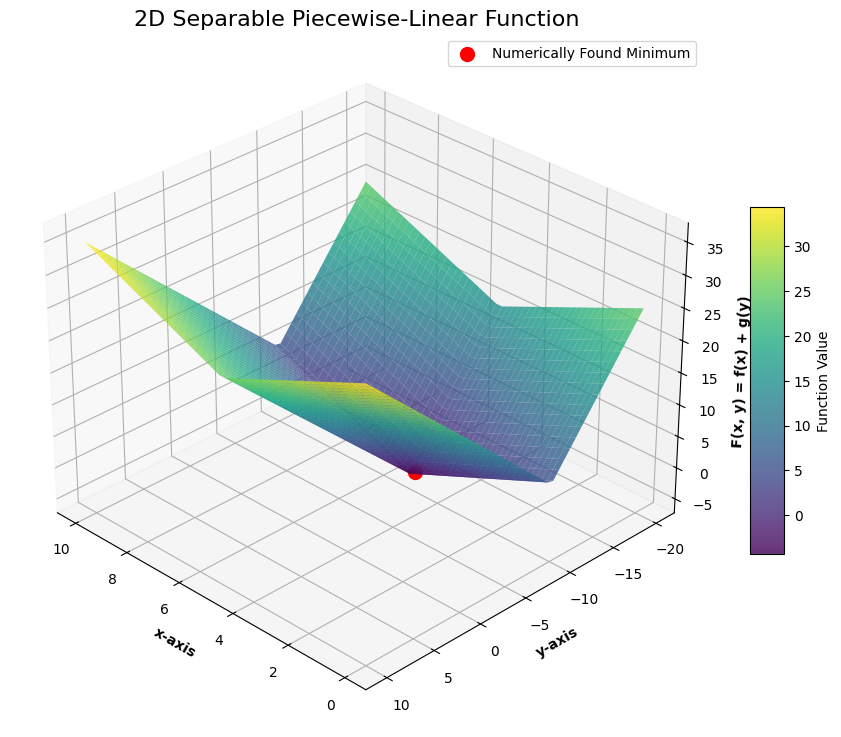

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the 1D Piecewise-Linear Functions ---

# f(x): A symmetric V-shape with its minimum at x=5
x_pts = [0.0, 5.0, 10.0]
fx_pts = [10.0, 0.0, 10.0]

# g(y): An asymmetric function with its minimum at y=-10
y_pts = [-20.0, -10.0, 10.0]
gy_pts = [15.0, -5.0, 25.0]

# Create helper functions to evaluate f(x) and g(y) for plotting
# np.interp is a NumPy function for 1D piecewise-linear interpolation.
def eval_f(x_val):
    return np.interp(x_val, x_pts, fx_pts)

def eval_g(y_val):
    return np.interp(y_val, y_pts, gy_pts)

# --- 2. Generate Data for the 2D Surface Plot ---

# Create a grid of points to plot the surface
x_grid = np.linspace(0, 10, 50)
y_grid = np.linspace(-20, 10, 50)
X, Y = np.meshgrid(x_grid, y_grid)

# Evaluate the 2D function F(x,y) = f(x) + g(y) on the grid
Z = eval_f(X) + eval_g(Y)

# --- 3. Find the Minimum Point Numerically (No Gurobi) ---

# Find the minimum value on our Z grid
min_z_val = Z.min()

# Find the index (row, col) of the minimum value in the 2D grid
min_index = np.unravel_index(np.argmin(Z), Z.shape)

# Get the x and y coordinates corresponding to that minimum point
min_x_val = X[min_index]
min_y_val = Y[min_index]

print("--- Numeric Calculation (No Gurobi) ---")
print(f"Minimum point found at: (x, y) = ({min_x_val:.2f}, {min_y_val:.2f})")
print(f"Minimum function value F(x,y) = {min_z_val:.2f}")


# --- 4. Visualize the 2D Function and the Minimum Point ---

# Create the 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection='3d')

# Plot the surface
surface = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')

# Plot the optimal point we found with NumPy
# We make it a large, red dot so it's clearly visible.
ax.scatter(min_x_val, min_y_val, min_z_val, color='red', s=100, depthshade=True, label='Numerically Found Minimum')

# Add labels and title
ax.set_xlabel('x-axis', fontweight='bold')
ax.set_ylabel('y-axis', fontweight='bold')
ax.set_zlabel('F(x, y) = f(x) + g(y)', fontweight='bold')
ax.set_title('2D Separable Piecewise-Linear Function', fontsize=16)
ax.legend()
fig.colorbar(surface, shrink=0.5, aspect=10, label='Function Value')

# Set a nice viewing angle
ax.view_init(elev=30, azim=135)

plt.show()

--- Numeric Calculation on Fewer Random Samples ---
Minimum point found among samples at: (x, y) = (0.07, -0.43)
Minimum function value Z = 0.44


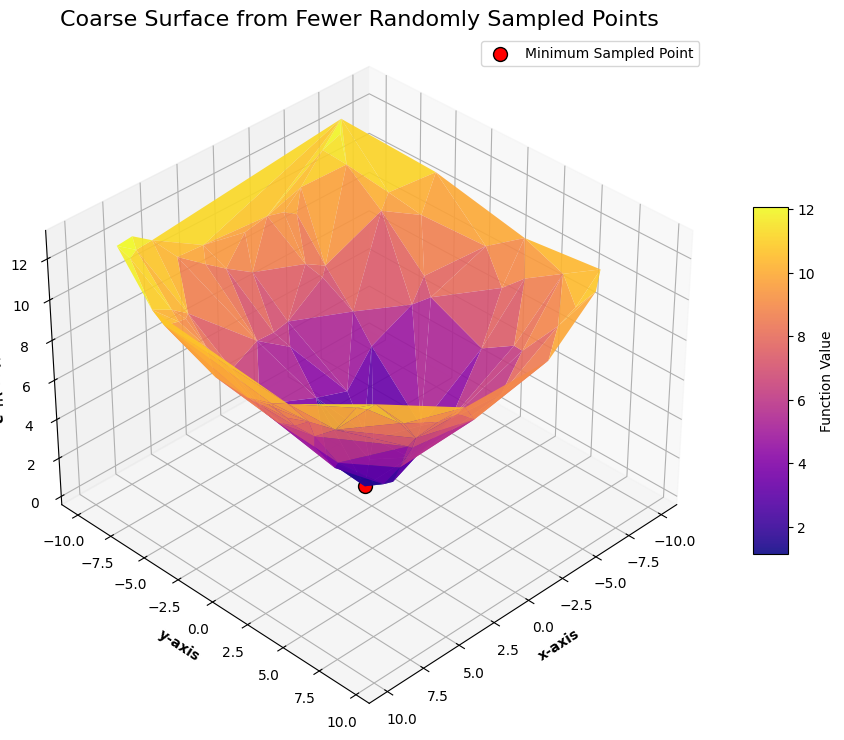

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate Fewer Randomly Sampled Points ---

# Decrease the number of points from 600 to 80
num_points = 100

# Sample x and y from a uniform distribution between -10 and 10.
x_random = np.random.uniform(-10, 10, num_points)
y_random = np.random.uniform(-10, 10, num_points)

# --- 2. Calculate Z for each random point ---
Z_random = np.sqrt(x_random**2 + y_random**2)

# --- 3. Find the minimum among the random samples ---
min_idx = np.argmin(Z_random)
min_x = x_random[min_idx]
min_y = y_random[min_idx]
min_z = Z_random[min_idx]

print("--- Numeric Calculation on Fewer Random Samples ---")
print(f"Minimum point found among samples at: (x, y) = ({min_x:.2f}, {min_y:.2f})")
print(f"Minimum function value Z = {min_z:.2f}")


# --- 4. Visualize the Function from Fewer Random Samples ---

# Create the 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection='3d')

# Use plot_trisurf which is designed to create a surface from scattered (x,y,z) points.
surface = ax.plot_trisurf(x_random, y_random, Z_random, cmap='plasma', linewidth=0.2, antialiased=True, alpha=0.9)

# Plot the minimum point found among the samples
ax.scatter(min_x, min_y, min_z, color='red', s=100, ec='black', zorder=10, depthshade=True, label='Minimum Sampled Point')

# Add labels and title
ax.set_xlabel('x-axis', fontweight='bold')
ax.set_ylabel('y-axis', fontweight='bold')
ax.set_zlabel('Z = ||(x,y)||_2', fontweight='bold')
ax.set_title('Coarse Surface from Fewer Randomly Sampled Points', fontsize=16)
ax.legend()
fig.colorbar(surface, shrink=0.5, aspect=10, label='Function Value')

# Set a viewing angle
ax.view_init(elev=35, azim=45)

plt.show()